In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Railway_info.csv")

In [3]:
print("First 10 rows:")
print(df.head(10))

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


First 10 rows:
   Train_No    Train_Name           Source_Station_Name  \
0       107  SWV-MAO-VLNK               SAWANTWADI ROAD   
1       108  VLNK-MAO-SWV                   MADGOAN JN.   
2       128  MAO-KOP SPEC                   MADGOAN JN.   
3       290  PALACE ON WH             DELHI-SAFDAR JANG   
4       401  BSB BHARATDA                    AURANGABAD   
5       421  LKO-SVDK FTR                   LUCKNOW JN.   
6       422  SVDK-LKO FTR  SHRI MATA VAISHNO DEVI KATRA   
7       477  FTR TRAIN NO                         SIRSA   
8       502  RJPB-UMB FTR        RAJENDRANAGAR TERMINAL   
9       504  PNBE-BTI FTR                     PATNA JN.   

             Destination_Station_Name       days  
0                         MADGOAN JN.   Saturday  
1                     SAWANTWADI ROAD     Friday  
2  CHHATRAPATI SHAHU MAHARAJ TERMINUS     Friday  
3                   DELHI-SAFDAR JANG  Wednesday  
4                        VARANASI JN.   Saturday  
5        SHRI MATA VAISHNO DE

In [4]:
print("\nBasic Statistics:")
print("Total Trains:", len(df))
print("Unique Train Numbers:", df["Train_No"].nunique())
print("Unique Source Stations:", df["Source_Station_Name"].nunique())
print("Unique Destination Stations:", df["Destination_Station_Name"].nunique())
print("Operating Days:", df["days"].nunique())

print("\nTop 5 Source Stations:")
print(df["Source_Station_Name"].value_counts().head(5))

print("\nTop 5 Destination Stations:")
print(df["Destination_Station_Name"].value_counts().head(5))



Basic Statistics:
Total Trains: 11113
Unique Train Numbers: 11113
Unique Source Stations: 921
Unique Destination Stations: 924
Operating Days: 14

Top 5 Source Stations:
Source_Station_Name
CST-MUMBAI       513
SEALDAH          372
CHENNAI BEACH    339
HOWRAH JN.       338
KALYAN JN        285
Name: count, dtype: int64

Top 5 Destination Stations:
Destination_Station_Name
CST-MUMBAI       514
SEALDAH          373
CHENNAI BEACH    342
HOWRAH JN.       337
KALYAN JN        284
Name: count, dtype: int64


In [5]:
df["Source_Station_Name"] = df["Source_Station_Name"].str.upper()
df["Destination_Station_Name"] = df["Destination_Station_Name"].str.upper()
df["Train_Name"] = df["Train_Name"].str.upper()
df["days"] = df["days"].str.capitalize()

print("\nData Cleaning Completed")



Data Cleaning Completed


In [6]:
saturday_trains = df[df["days"] == "Saturday"]
print("\nSaturday Trains:", len(saturday_trains))

specific_station = "NEW DELHI"
from_station = df[df["Source_Station_Name"] == specific_station]
print(f"Trains from {specific_station}:", len(from_station))



Saturday Trains: 1441
Trains from NEW DELHI: 107


In [7]:
trains_by_station = (
    df.groupby("Source_Station_Name")["Train_No"]
    .count()
    .sort_values(ascending=False)
)

print("\nTop 10 Busiest Stations:")
print(trains_by_station.head(10))

avg_trains_per_day = (
    df.groupby(["Source_Station_Name", "days"])["Train_No"]
    .count()
    .groupby(level=0)
    .mean()
)

print("\nAverage Trains Per Day (Top 10):")
print(avg_trains_per_day.sort_values(ascending=False).head(10))



Top 10 Busiest Stations:
Source_Station_Name
CST-MUMBAI       513
SEALDAH          372
CHENNAI BEACH    339
HOWRAH JN.       338
KALYAN JN        285
THANE            186
PANVEL           141
TAMBARAM         140
MOOR MARKET      135
VELACHEERY       115
Name: Train_No, dtype: int64

Average Trains Per Day (Top 10):
Source_Station_Name
CST-MUMBAI       51.300000
SEALDAH          41.333333
KALYAN JN        40.714286
HOWRAH JN.       30.727273
THANE            26.571429
CHENNAI BEACH    24.214286
TAMBARAM         20.000000
PANVEL           17.625000
VELACHEERY       16.428571
NEW DELHI        15.285714
Name: Train_No, dtype: float64


In [8]:
df["Day_Category"] = df["days"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

df["Journey_Type"] = df.apply(
    lambda x: "Local/Shuttle"
    if x["Source_Station_Name"] == x["Destination_Station_Name"]
    else "Long-distance",
    axis=1
)

print("\nDay Category Count:")
print(df["Day_Category"].value_counts())

print("\nJourney Type Count:")
print(df["Journey_Type"].value_counts())



Day Category Count:
Day_Category
Weekday    8240
Weekend    2873
Name: count, dtype: int64

Journey Type Count:
Journey_Type
Long-distance    11098
Local/Shuttle       15
Name: count, dtype: int64


In [9]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_distribution = df["days"].value_counts().reindex(day_order)


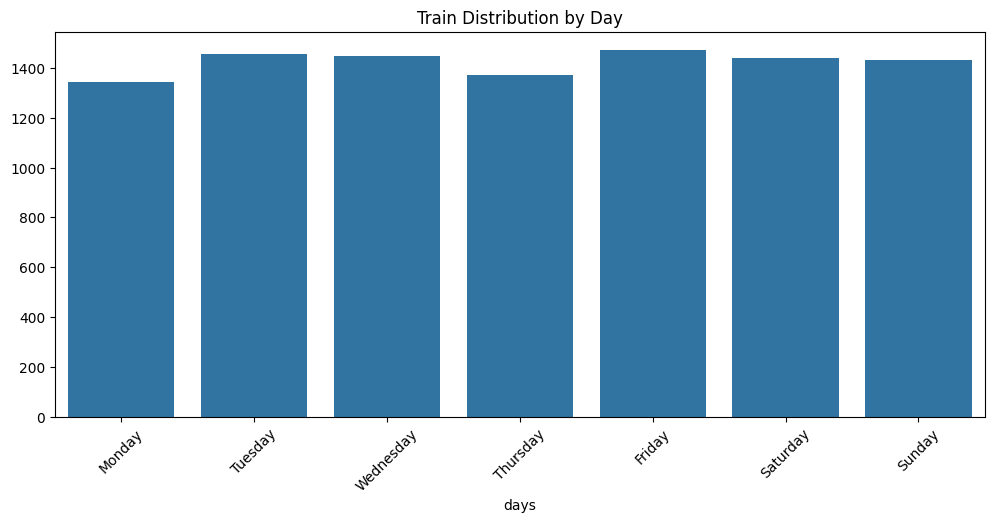

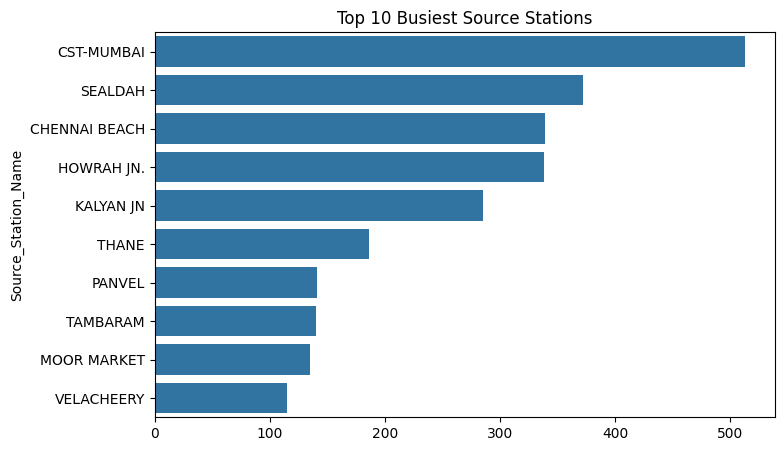

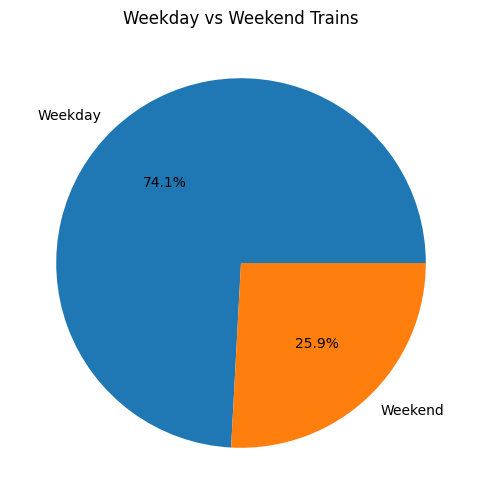

In [10]:
plt.figure(figsize=(12,5))
sns.barplot(x=day_distribution.index, y=day_distribution.values)
plt.title("Train Distribution by Day")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(
    x=trains_by_station.head(10).values,
    y=trains_by_station.head(10).index
)
plt.title("Top 10 Busiest Source Stations")
plt.show()

plt.figure(figsize=(6,6))
df["Day_Category"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Weekday vs Weekend Trains")
plt.ylabel("")
plt.show()

In [11]:
print("\nPROJECT SUMMARY")
print("----------------")
print("Total Trains:", len(df))
print("Busiest Day:", day_distribution.idxmax())
print("Busiest Station:", trains_by_station.idxmax())


PROJECT SUMMARY
----------------
Total Trains: 11113
Busiest Day: Friday
Busiest Station: CST-MUMBAI
